In [1]:
import sympy as sp
import numpy as np

from composipy import OrthotropicMaterial, LaminateProperty, PlateStructure

In [2]:
E1 = 60800
E2 = 58250
v12 = 0.07
G12 = 4550
t = 0.21

mat_1 = OrthotropicMaterial(E1, E2, v12, G12, t)

In [3]:
from composipy import LaminateProperty
stacking = [-45, 45, 90, 0, 0, 0, 0, 90, 45, -45]
laminate1 = LaminateProperty(stacking, mat_1)

In [18]:
constraints = {    
    'x0' : ['TX', 'TY', 'TZ', 'RX', 'RY', 'RZ'],
    'xa' : ['TX', 'TY', 'TZ', 'RX', 'RY', 'RZ'],
    'y0' : ['TX', 'TY', 'TZ', 'RX', 'RY', 'RZ'],
    'yb' : ['TX', 'TY', 'TZ', 'RX', 'RY', 'RZ']
    }
panel = PlateStructure(laminate1, 760, 360, m=6, n=6, Nxx=-1, constraints=constraints, plane='yz')

In [19]:
panel.buckling_analysis()

(array([22.67586191, 23.3287317 , 28.97536301, 38.2703791 , 59.17872083]),
 array([[ 6.19064581e-01,  2.81755108e-14, -1.28139164e-14,
          2.30155611e+00,  2.67467857e-15],
        [-2.47830398e-14,  1.35598355e-03, -3.25080473e-03,
          8.71558114e-15, -9.27983059e-03],
        [ 1.92303530e-01,  6.24592937e-15,  1.28024995e-14,
         -4.78740684e-01, -5.77162994e-14],
        [-2.44298893e-14,  2.26688221e-04,  2.13156544e-03,
          1.97181017e-14, -7.94981471e-04],
        [ 1.22595532e-02,  1.23934268e-14,  9.13048044e-15,
         -6.11844456e-02,  4.31047877e-15],
        [ 7.64023951e-15, -6.19850632e-05,  4.92329241e-04,
         -9.88824318e-15, -4.13031483e-04],
        [ 3.35734054e-13, -8.40439800e+00, -1.89697735e+01,
         -2.21100183e-13, -1.01367429e+01],
        [ 9.68439549e-03,  6.75013561e-15, -8.14694088e-15,
         -6.59955471e-02,  8.12961024e-14],
        [-2.39237890e-14,  9.94188202e-01, -5.23009272e-01,
          4.91731940e-15, -1.3858

d:\programs\Anaconda\lib\site-packages\pyvista\jupyter\notebook.py:58: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


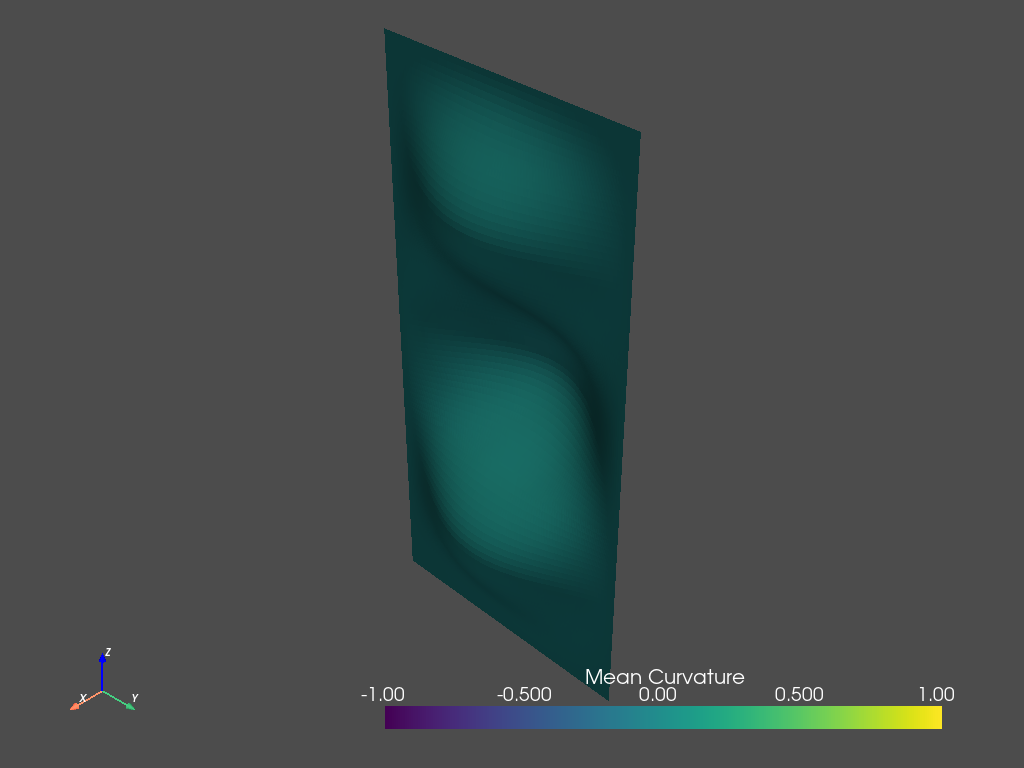

In [20]:
panel.plot_eigenvalue(ngridx=100, ngridy=100, factor=1000)

In [16]:
K, _ = panel.calc_K_KG()

In [18]:
K.shape

(27, 27)

In [17]:
sp.Matrix(K)

Matrix([
[     65.6375469509251,                     0,      -5.4726384112008,                     0,  1.00825817278934e-16,                     0,     -9.44498589582763,                     0,     0.663005524756819, -5.49959003339639e-17,                     0, -5.49959003339639e-17,                     0,      -2.3102935243505,                     0,   6.7494968591683e-17,                     0, -5.55514144787514e-19,                     0,  3.44679167023628e-19,                     0,  1.71623872975523e-14,                     0, -1.04053354460149e-15,                     0, -5.73452622379611e-20,                     0],
[                    0,      9.38329032317682,                     0, -1.00825817278934e-16,                     0,   2.7497950166982e-17,                     0,     -1.06567996630951,                     0,                     0,  1.28323767445916e-16,                     0,       2.3102935243505,                     0,    -0.630080052095591,                     0,

In [2]:
import sympy as sp

In [3]:
f1g1, f1g2, f2g1, f2g2 = sp.symbols(['f1g1', 'f1g2', 'f2g1', 'f2g2'])
af1g1, af1g2, af2g1, af2g2 = sp.symbols(['af1g1', 'af1g2', 'af2g1', 'af2g2'])
bf1g1, bf1g2, bf2g1, bf2g2 = sp.symbols(['bf1g1', 'bf1g2', 'bf2g1', 'bf2g2'])

In [8]:
u = sp.Matrix([[f1g1, f1g2, f2g1, f2g2]])
ua = sp.Matrix([[af1g1, af1g2, af2g1, af2g2]])
ub = sp.Matrix([[bf1g1, bf1g2, bf2g1, bf2g2]])


In [10]:
k_ex1 = u.T * u
k_ex1

Matrix([
[  f1g1**2, f1g1*f1g2, f1g1*f2g1, f1g1*f2g2],
[f1g1*f1g2,   f1g2**2, f1g2*f2g1, f1g2*f2g2],
[f1g1*f2g1, f1g2*f2g1,   f2g1**2, f2g1*f2g2],
[f1g1*f2g2, f1g2*f2g2, f2g1*f2g2,   f2g2**2]])

In [12]:
k_ex1.T == k_ex1 # check de simetria

True

In [7]:
u_values = f1g1 + f1g2 + f2g1 + f2g2
u_values**2

(f1g1 + f1g2 + f2g1 + f2g2)**2

In [21]:
k_ex2 = ua.T * ub
k_ex2

Matrix([
[af1g1*bf1g1, af1g1*bf1g2, af1g1*bf2g1, af1g1*bf2g2],
[af1g2*bf1g1, af1g2*bf1g2, af1g2*bf2g1, af1g2*bf2g2],
[af2g1*bf1g1, af2g1*bf1g2, af2g1*bf2g1, af2g1*bf2g2],
[af2g2*bf1g1, af2g2*bf1g2, af2g2*bf2g1, af2g2*bf2g2]])

In [22]:
k_ex2.T == k_ex2

False

In [19]:
k_ex3 = ua.T * ub + ub.T * ua
k_ex3

Matrix([
[            2*af1g1*bf1g1, af1g1*bf1g2 + af1g2*bf1g1, af1g1*bf2g1 + af2g1*bf1g1, af1g1*bf2g2 + af2g2*bf1g1],
[af1g1*bf1g2 + af1g2*bf1g1,             2*af1g2*bf1g2, af1g2*bf2g1 + af2g1*bf1g2, af1g2*bf2g2 + af2g2*bf1g2],
[af1g1*bf2g1 + af2g1*bf1g1, af1g2*bf2g1 + af2g1*bf1g2,             2*af2g1*bf2g1, af2g1*bf2g2 + af2g2*bf2g1],
[af1g1*bf2g2 + af2g2*bf1g1, af1g2*bf2g2 + af2g2*bf1g2, af2g1*bf2g2 + af2g2*bf2g1,             2*af2g2*bf2g2]])

In [20]:
k_ex3.T == k_ex3

True